<a href="https://colab.research.google.com/github/francescopassante/GETMeshClassifier/blob/main/GET/src/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%rm -rf GETMeshClassifier/
!git clone https://github.com/francescopassante/GETMeshClassifier.git
%cd /content

Cloning into 'GETMeshClassifier'...
remote: Enumerating objects: 433, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 433 (delta 14), reused 31 (delta 10), pack-reused 395 (from 1)
Receiving objects: 100% (433/433), 635.94 KiB | 11.36 MiB/s, done.
Resolving deltas: 100% (139/139), done.
/content


In [2]:
import GET
import GEUtils
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

MAX_NEIGH = 50

path = ""
if MAX_NEIGH == 200:
  # Download dataset with 200 neigbhors for each vertex
  !gdown 1e96CxX_JXAUGjYM1EOOtglIihpTFLN4J
  !unzip -q SHREC11_200NEIGH.zip
  path = "../../../SHREC11_200NEIGH/"
if MAX_NEIGH == 50:
  # Downloads dataset with 50 neighbors for each vertex
  !gdown 1TVBnGLPVMzu3udob2lZVbBKHH6J3tqN9
  !unzip -q SHREC11_50NEIGH.zip
  path = "../../../SHREC11_50NEIGH/"

Downloading...
From (original): https://drive.google.com/uc?id=1e96CxX_JXAUGjYM1EOOtglIihpTFLN4J
From (redirected): https://drive.google.com/uc?id=1e96CxX_JXAUGjYM1EOOtglIihpTFLN4J&confirm=t&uuid=6e52181d-74f9-4fa4-8a77-91c4e907f7c0
To: /content/SHREC11_200NEIGH.zip
100% 2.40G/2.40G [00:25<00:00, 93.4MB/s]


In [3]:
%cd GETMeshClassifier/GET/src

/content/GETMeshClassifier/GET/src


In [26]:
device = "cuda" if torch.cuda.is_available() else "cpu"

data = GET.load_data(
    mesh_directory=f"{path}processed/",
    labels_file=f"{path}classes.txt",
    N=9,
    train_percent=0.02,
    val_percent=0.01,
    device=device,
)

print(
    f"Train: {len(data['train_loader'])}  "
    f"Val: {len(data['val_loader'])}  "
    f"Test: {len(data['test_loader'])}"
)

Train: 11  Val: 5  Test: 582


In [27]:
model = GET.GETClassifier(N=9, channels=12, heads = 2, out_classes=30).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.1)
num_params = sum(p.numel() for p in model.parameters())
print(f"Model has {num_params} parameters")

Model has 9114 parameters


In [ ]:
train_loss_hist, val_loss_hist = GET.train(
    model=model,
    dataloader=data["train_loader"],
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    device=device,
    epochs=10,
    accumulation_steps=4,
    val_loader=data["val_loader"],
    patience=15,
    train_filenumbers=data["train_filenumbers"],
    val_filenumbers=data["val_filenumbers"],
    test_filenumbers=data["test_filenumbers"],
)

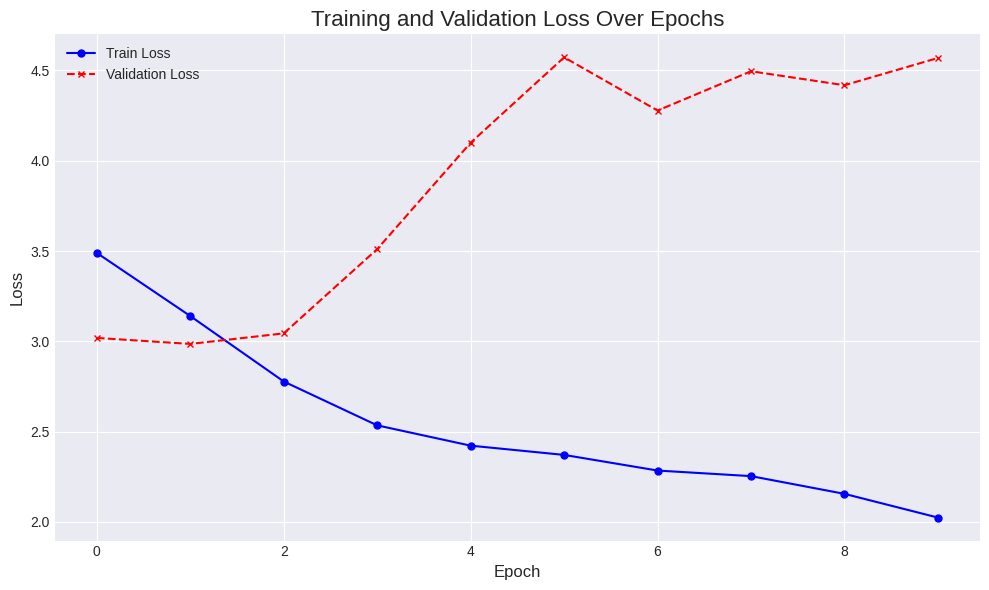

In [21]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid') # Apply a dark grid style
plt.figure(figsize=(10, 6))
plt.plot(train_loss_hist, label="Train Loss", color='blue', linestyle='-', marker='o', markersize=5)
plt.plot(val_loss_hist, label="Validation Loss", color='red', linestyle='--', marker='x', markersize=5)
plt.title('Training and Validation Loss Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True) # Ensure grid is explicitly on
plt.tight_layout() # Adjust layout for better fit
plt.show()

In [ ]:
test_acc = GET.validate(
    model=model,
    dataloader=data["test_loader"],
    criterion = criterion,
    device=device
)
print(f"Test Accuracy: {test_acc:.2f}%")